# In this jupyter notebook file, we will replicate the results reported in the paper : Controllability of Complex networks 

In [4]:
try:
    import networkx  as nx
    import matplotlib.pyplot as plt

except ImportError:
    !pip install networkx matplotlib
    import networkx  as nx
    import matplotlib.pyplot as plt

Following is an utility function that will be used to draw the directed network 

In [20]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def plot_control_graph(G, matched_nodes, matching):
    """
    Plot a directed graph highlighting:
    - matched nodes
    - unmatched/driver nodes
    - maximum-matching edges
    """

    pos = nx.spring_layout(G, seed=42)

    # Recover matching edges in the original directed graph
    matching_edges = [
        (u, v)
        for u, v in G.edges()
        if matching.get((u, "out")) == (v, "in")
    ]

    # Node colors
    node_colors = [
        "lightgreen" if node in matched_nodes else "white"
        for node in G.nodes()
    ]

    # Edge colors
    edge_colors = [
        "purple" if edge in matching_edges else "gray"
        for edge in G.edges()
    ]

    nx.draw(
        G,
        pos,
        with_labels=True,
        arrows=True,
        node_color=node_colors,
        edge_color=edge_colors,
        edgecolors="black",
        node_size=1500,
        width=2,
        font_size=11
    )

    # Legend
    legend_items = [
        Patch(facecolor="lightgreen", edgecolor="black", label="Matched node"),
        Patch(facecolor="white", edgecolor="black", label="Unmatched / Driver node"),
        Line2D([0], [0], color="purple", lw=2, label="Matching edge"),
        Line2D([0], [0], color="gray", lw=2, label="Non-matching edge")
    ]

    plt.legend(handles=legend_items)
    plt.show()

We will generate the Figure 1(b) diagram and we will be using the networkx library for this 

In [ ]:
G = nx.DiGraph()

G.add_edges_from([("x1","x2"), ("x2","x3"), ("x3","x4")])

x

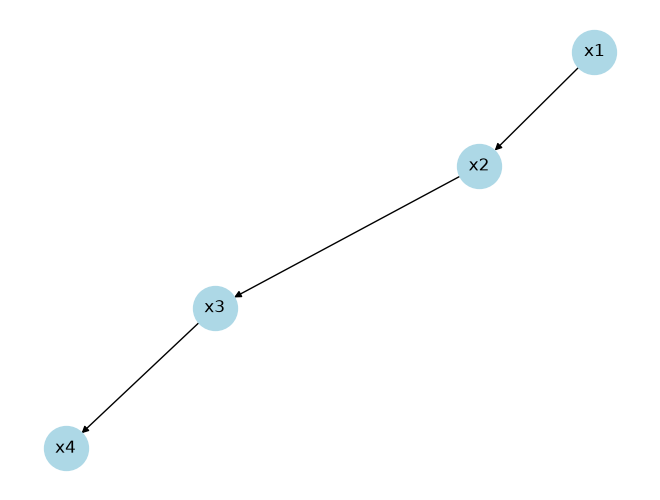

In [10]:
nx.draw(G, with_labels=True, node_color="lightblue", node_size=1000, arrows=True)
plt.show()

We will now perform maximum matching on this network using bipartite algorithm

In [12]:
# Let's create a bipartite graph from the directed graph G 
# this bipartite graph will be used to determine the maximum matching


B = nx.Graph()

left_nodes = [(node,"out") for node in G.nodes()]
right_nodes = [(node,"in") for node in G.nodes()]

B.add_nodes_from(left_nodes, bipartite=0)  # bipartite=0 is on the left side, the out nodes who sends the edge
B.add_nodes_from(right_nodes, bipartite=1) # bipartite=1 is on the right side, the in nodes who receives the edge

for u,v in G.edges():
    B.add_edge((u,"out"), (v,"in")) # connect left and right according to the directed edges in G

Calculate the maximum matching from the bipartite graph 

In [ ]:
matching = nx.algorithms.bipartite.maximum_matching(
    B,
    top_nodes=left_nodes # tells the algorithm which nodes are on the left side of the bipartite graph
)

print(matching)

{('x2', 'out'): ('x3', 'in'), ('x3', 'out'): ('x4', 'in'), ('x1', 'out'): ('x2', 'in'), ('x2', 'in'): ('x1', 'out'), ('x4', 'in'): ('x3', 'out'), ('x3', 'in'): ('x2', 'out')}


In [14]:
matched_nodes = { node for node in G.nodes() if (node,"in") in matching }

unmatched_nodes = set(G.nodes()) - matched_nodes

print("Matched nodes:", matched_nodes)  
print("Unmatched nodes:", unmatched_nodes)

Matched nodes: {'x2', 'x4', 'x3'}
Unmatched nodes: {'x1'}


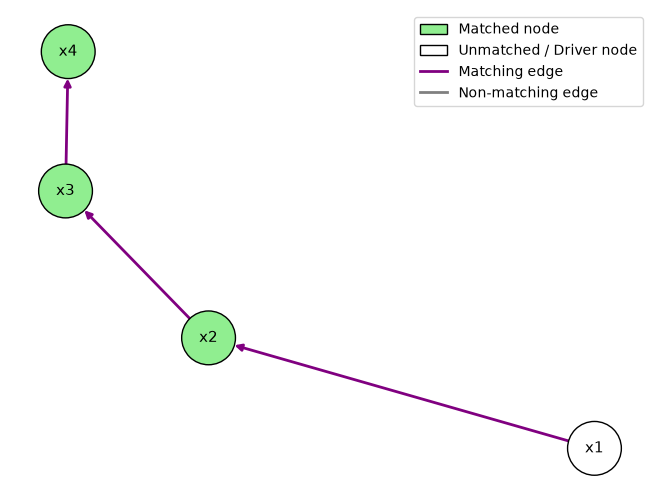

In [19]:
plot_control_graph(G, matched_nodes, matching)

Figure 1e and its corresponding maximum matching

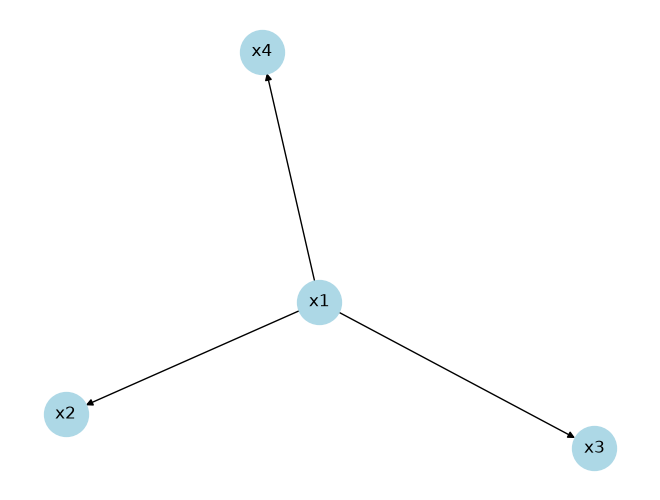

In [22]:
G = nx.DiGraph()

G.add_edges_from([("x1","x2"), ("x1","x3"), ("x1","x4")])
nx.draw(G, with_labels=True, node_color="lightblue", node_size=1000, arrows=True)
plt.show()


{('x1', 'out'): ('x2', 'in'), ('x2', 'in'): ('x1', 'out')}
Matched nodes: {'x2'}
Unmatched nodes: {'x1', 'x4', 'x3'}


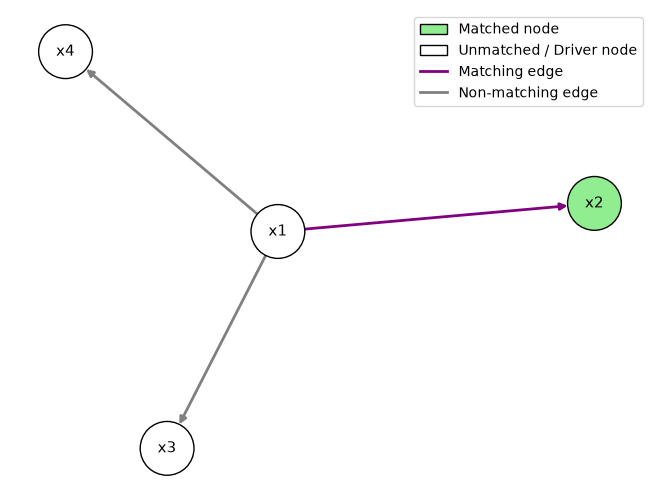

In [23]:
B = nx.Graph()

left_nodes = [(node,"out") for node in G.nodes()]
right_nodes = [(node,"in") for node in G.nodes()]

B.add_nodes_from(left_nodes, bipartite=0)  # bipartite=0 is on the left side, the out nodes who sends the edge
B.add_nodes_from(right_nodes, bipartite=1) # bipartite=1 is on the right side, the in nodes who receives the edge

for u,v in G.edges():
    B.add_edge((u,"out"), (v,"in")) 

matching = nx.algorithms.bipartite.maximum_matching(
    B,
    top_nodes=left_nodes # tells the algorithm which nodes are on the left side of the bipartite graph
)

print(matching)

matched_nodes = { node for node in G.nodes() if (node,"in") in matching }

unmatched_nodes = set(G.nodes()) - matched_nodes

print("Matched nodes:", matched_nodes)  
print("Unmatched nodes:", unmatched_nodes)

plot_control_graph(G, matched_nodes, matching)

We will now plot figure 1h

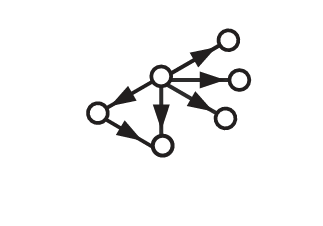

We will generalize and use the following function for the entire works we have been doing so far. this will 
- plot the network
- calculate the maximum matching
- show the network plot with matched nodes after maximum matching

In [26]:
def plot_network_and_matching(edges):
    G = nx.DiGraph()
    G.add_edges_from(edges)

    nx.draw(G, with_labels=True, node_color="lightblue", node_size=1000, arrows=True)
    plt.show()

    B = nx.Graph()
    left_nodes = [(node, "out") for node in G.nodes()]
    right_nodes = [(node, "in") for node in G.nodes()]

    B.add_nodes_from(left_nodes, bipartite=0)
    B.add_nodes_from(right_nodes, bipartite=1)
    B.add_edges_from([((u, "out"), (v, "in")) for u, v in G.edges()])

    matching = nx.algorithms.bipartite.maximum_matching(B, top_nodes=left_nodes)
    matched_nodes = {node for node in G.nodes() if (node, "in") in matching}
    unmatched_nodes = set(G.nodes()) - matched_nodes

    print("Matched nodes:", matched_nodes)
    print("Unmatched nodes:", unmatched_nodes)

    plot_control_graph(G, matched_nodes, matching)

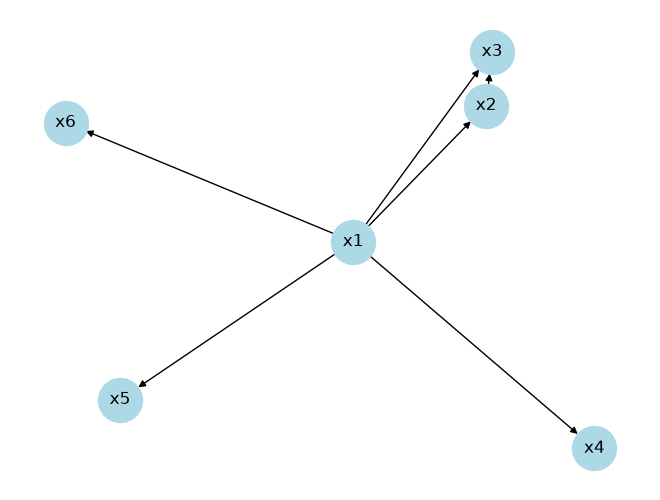

Matched nodes: {'x2', 'x3'}
Unmatched nodes: {'x1', 'x6', 'x4', 'x5'}


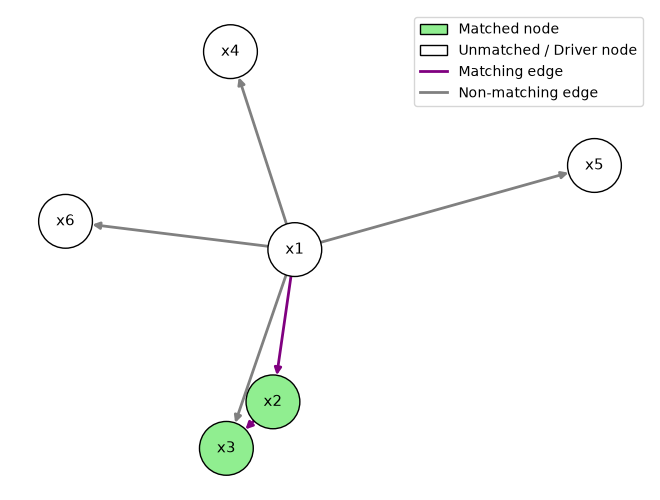

In [28]:
edges = [("x1","x2"),("x1","x3"),("x2","x3"),("x1","x6"),("x1","x5"),('x1','x4')]

plot_network_and_matching(edges)